---
## PHẦN 0: Setup & Cài đặt môi trường

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 0.1 — CÀI ĐẶT MÔI TRƯỜNG (PP-OCRv6 + VLMs)          ║
# ║  ⚠️ Cell này sẽ RESTART runtime sau khi cài xong!           ║
# ╚══════════════════════════════════════════════════════════════╝
import subprocess, sys, os, time

print("1. Đang cài đặt PaddlePaddle GPU Stable tương thích CUDA 12...")
subprocess.run([sys.executable, "-m", "pip", "install", "paddlepaddle-gpu",
                "-i", "https://www.paddlepaddle.org.cn/packages/stable/cu126/", "--quiet"])

print("2. Đang cài đặt PaddleOCR 3.x...")
subprocess.run([sys.executable, "-m", "pip", "install", "paddleocr>=3.0.0",
                "pandas", "pyarrow", "tqdm", "Pillow", "--quiet"])

print("3. Vá lỗi liên kết hệ thống CUDA libs...")
libs = ["nvidia-nccl-cu12==2.28.9", "nvidia-cudnn-cu12==9.19.0.56", "nvidia-cusparselt-cu12==0.7.1"]
for lib in libs:
    subprocess.run([sys.executable, "-m", "pip", "install", lib, "--force-reinstall", "--no-deps", "--quiet"])

print("\n🔥 HOÀN THÀNH SETUP PP-OCRv6!")
print("⚠️  RESTART RUNTIME SAU 3 GIÂY...")
print("👉 Sau khi restart, chạy tiếp từ CELL 0.2")
time.sleep(3)
os.kill(os.getpid(), 9)

1. Đang cài đặt PaddlePaddle GPU Stable tương thích CUDA 12...
2. Đang cài đặt PaddleOCR 3.x...
3. Vá lỗi liên kết hệ thống CUDA libs...

🔥 HOÀN THÀNH SETUP PP-OCRv6!
⚠️  RESTART RUNTIME SAU 3 GIÂY...
👉 Sau khi restart, chạy tiếp từ CELL 0.2


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 0.2 — VERIFY ENV & CONFIG CHUNG                       ║
# ╚══════════════════════════════════════════════════════════════╝
import paddle
import paddleocr
from paddleocr import PaddleOCR

print(f"PaddlePaddle version : {paddle.__version__}")
print(f"PaddleOCR version    : {paddleocr.__version__}")
print(f"GPU compiled         : {paddle.is_compiled_with_cuda()}")
print(f"GPU device count     : {paddle.device.cuda.device_count()}")

paddle.utils.run_check()

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


PaddlePaddle version : 3.3.1
PaddleOCR version    : 3.7.0
GPU compiled         : True
GPU device count     : 1
Running verify PaddlePaddle program ... 


/usr/local/lib/python3.12/dist-packages/paddle/pir/math_op_patch.py:241: UserWarning: Tensor do not have 'place' interface for pir graph mode, try not to use it. None will be returned.
  warnings.warn(


PaddlePaddle works well on 1 GPU.
PaddlePaddle is installed successfully! Let's start deep learning with PaddlePaddle now.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 0.3 — CẤU HÌNH CHUNG CHO TOÀN BỘ PIPELINE            ║
# ╚══════════════════════════════════════════════════════════════╝
import pandas as pd
import torch
import gc
import time
import json
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image

# =====================================================================
# 🎯 CẤU HÌNH — THAY ĐỔI CÁC GIÁ TRỊ NÀY CHO PHÙ HỢP
# =====================================================================
VIDEO_ID       = "L25_V001"
FRAMES_DIR     = Path(f"/content/drive/MyDrive/{VIDEO_ID}")
OUTPUT_DIR     = Path("/content/mmrs_lmf/ocr_results")
CONF_THRESHOLD = 0.75      # Ngưỡng confidence để escalate qua VLM
MARGIN_RATIO   = 0.15      # Nới bbox khi crop ảnh (dùng cho test so sánh)
MIN_SIDE       = 64        # Crop quá nhỏ sẽ bị upscale
# =====================================================================

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"📂 Video ID     : {VIDEO_ID}")
print(f"📂 Frames Dir   : {FRAMES_DIR}")
print(f"📂 Output Dir   : {OUTPUT_DIR}")
print(f"🔧 Conf Threshold: {CONF_THRESHOLD}")

📂 Video ID     : L25_V001
📂 Frames Dir   : /content/drive/MyDrive/L25_V001
📂 Output Dir   : /content/mmrs_lmf/ocr_results
🔧 Conf Threshold: 0.75


---
## PHẦN 1: PP-OCRv6 — Pass 1 (Detection + Recognition)

Giữ nguyên flow PP-OCRv6 như notebook gốc:
- Detect text trong tất cả frames
- Recognition text + confidence score
- Lưu kết quả thô vào parquet

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 1.1 — KHỞI TẠO PP-OCRv6 ENGINE (ĐÃ CẬP NHẬT DICT)      ║
# ╚══════════════════════════════════════════════════════════════╝
from paddleocr import PaddleOCR

ocr_engine = PaddleOCR(
    ocr_version="PP-OCRv6",
    lang="vi",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    text_det_limit_side_len=1216,
    text_det_thresh=0.35,
    text_det_box_thresh=0.6,
    text_det_unclip_ratio=2.0,        # mặc định ~1.5, nới rộng hơn để không cắt dấu
    text_rec_score_thresh=0.0,
)
print("✅ PP-OCRv6 engine đã cấu hình lại từ điển tiếng Việt thành công!")

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.


✅ PP-OCRv6 engine đã cấu hình lại từ điển tiếng Việt thành công!


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 1.2 — CHẠY PP-OCRv6 TRÊN TẤT CẢ FRAMES               ║
# ╚══════════════════════════════════════════════════════════════╝
import ast

frame_files = sorted(FRAMES_DIR.glob("*.jpg"))
print(f"📸 Tìm thấy {len(frame_files)} frames trong {FRAMES_DIR}")

records = []
t_start_ppocr = time.time()

for img_path in tqdm(frame_files, desc="PP-OCRv6 inference"):
    frame_id = img_path.stem
    result = ocr_engine.predict(str(img_path))

    for res in result:
        if "rec_texts" in res:
            texts  = res["rec_texts"]
            scores = res["rec_scores"]
            boxes  = res["dt_polys"]

            for idx, (text, score, poly) in enumerate(zip(texts, scores, boxes)):
                xs = [p[0] for p in poly]
                ys = [p[1] for p in poly]
                bbox = [min(xs), min(ys), max(xs), max(ys)]
                records.append({
                    "frame_id":   frame_id,
                    "frame_path": str(img_path),
                    "line_idx":   idx,
                    "bbox":       bbox,
                    "ocr_text":   text,
                    "confidence": score,
                })

t_ppocr_total = time.time() - t_start_ppocr
df_ocr = pd.DataFrame(records)
print(f"\n✅ PP-OCRv6 hoàn thành: {len(df_ocr)} text lines từ {len(frame_files)} frames")
print(f"⏱️  Tổng thời gian PP-OCRv6: {t_ppocr_total:.1f}s ({t_ppocr_total/len(frame_files):.2f}s/frame)")
df_ocr.head()

📸 Tìm thấy 438 frames trong /content/drive/MyDrive/L25_V001


PP-OCRv6 inference:   0%|          | 0/438 [00:00<?, ?it/s]


✅ PP-OCRv6 hoàn thành: 5109 text lines từ 438 frames
⏱️  Tổng thời gian PP-OCRv6: 260.0s (0.59s/frame)


,frame_id,frame_path,line_idx,bbox,ocr_text,confidence
0,001,/content/drive/MyDrive/L25_V001/001.jpg,0,"[396, 281, 886, 435]",THANHNIEN,0.997105
1,002,/content/drive/MyDrive/L25_V001/002.jpg,0,"[1, 25, 250, 101]",THANHNIEN,0.963616
2,002,/content/drive/MyDrive/L25_V001/002.jpg,1,"[986, 470, 1266, 685]",l,0.626709
3,003,/content/drive/MyDrive/L25_V001/003.jpg,0,"[1, 25, 250, 101]",THANHNIEN,0.950882
4,003,/content/drive/MyDrive/L25_V001/003.jpg,1,"[989, 473, 1264, 677]",l,0.655003


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 1.3 — LƯU KẾT QUẢ PASS 1 & CONFIDENCE GATING         ║
# ╚══════════════════════════════════════════════════════════════╝
pass1_path = OUTPUT_DIR / f"{VIDEO_ID}_ppocrv6_raw.parquet"
df_ocr.to_parquet(pass1_path, index=False)
print(f"💾 Đã lưu Pass 1 → {pass1_path}")

# Confidence gating
df_low_conf = df_ocr[df_ocr["confidence"] < CONF_THRESHOLD].copy()
n_total = len(df_ocr)
n_low   = len(df_low_conf)
print(f"\n🔍 Confidence Gating (threshold={CONF_THRESHOLD}):")
print(f"   ✅ High-conf: {n_total - n_low}/{n_total} ({(n_total-n_low)/n_total:.1%})")
print(f"   ⚠️  Low-conf:  {n_low}/{n_total} ({n_low/n_total:.1%}) → cần escalate qua VLM")
print(f"\n👉 Chạy tiếp CELL 2.1 để cài môi trường VLM (sẽ restart runtime).")

💾 Đã lưu Pass 1 → /content/mmrs_lmf/ocr_results/L25_V001_ppocrv6_raw.parquet

🔍 Confidence Gating (threshold=0.75):
   ✅ High-conf: 4882/5109 (95.6%)
   ⚠️  Low-conf:  227/5109 (4.4%) → cần escalate qua VLM

👉 Chạy tiếp CELL 2.1 để cài môi trường VLM (sẽ restart runtime).


## PHẦN 2: VINTERN 3B

In [ ]:
# Vintern-1B-v2 (InternVL2) tương thích transformers >= 4.37.2 (kể cả 4.46.x).
# Nếu Session A dùng transformers khác → khởi động lại Runtime trước khi chạy cell này.

!pip install -q transformers==4.44.2 accelerate einops timm sentencepiece bitsandbytes --upgrade-strategy only-if-needed

import importlib, torch, time
import pandas as pd

for lib in ["transformers", "torch", "einops", "bitsandbytes"]:
    try:
        print(f"  {lib}: {importlib.import_module(lib).__version__}")
    except Exception:
        print(f"  {lib}: ❌ Chưa cài")
print(f"  CUDA: {'✅ ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else '❌ Không có GPU!'}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 124.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 125.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ CELL 2 / 5 — TẢI VINTERN-3B-R-BETA (REASONING) + ĐỒNG BỘ THIẾT BỊ HẬU NẠP     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import sys
import gc
import importlib.util
import importlib.machinery
from types import ModuleType
import torch
import torch.nn as nn
import transformers
from transformers import AutoModel, AutoTokenizer, BitsAndBytesConfig
from torchvision import transforms
from torchvision.transforms.functional import InterpolationMode

# 🔥 FORCE CLEAN: Giải phóng thực thể cũ để tránh xung đột RAM
for old_var in ["vintern_model", "model"]:
    if old_var in globals():
        print(f"🔥 Đang giải phóng thực thể cũ khỏi bộ nhớ: {old_var}")
        del globals()[old_var]
gc.collect()
torch.cuda.empty_cache()

# 🔥 HACK SỬA LỖI FLASH_ATTN TRÊN T4 GPU
if "flash_attn" not in sys.modules:
    dummy_flash_attn = ModuleType("flash_attn")
    sys.modules["flash_attn"] = dummy_flash_attn
    old_find_spec = importlib.util.find_spec
    def new_find_spec(name, package=None):
        if name == "flash_attn":
            return importlib.machinery.ModuleSpec(name, None)
        return old_find_spec(name, package)
    importlib.util.find_spec = new_find_spec

# ──────────────────────────────────────────────────────────────────────────────
# Tiền xử lý ảnh theo chuẩn InternVL2
# ──────────────────────────────────────────────────────────────────────────────
_MEAN = (0.485, 0.456, 0.406)
_STD  = (0.229, 0.224, 0.225)

def _build_transform(input_size: int):
    return transforms.Compose([
        transforms.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
        transforms.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(mean=_MEAN, std=_STD),
    ])

def _best_aspect_ratio(ar, ratios, w, h, sz):
    best_diff, best = float("inf"), (1, 1)
    for r in ratios:
        diff = abs(ar - r[0] / r[1])
        if diff < best_diff or (diff == best_diff and w * h > 0.5 * sz * sz * r[0] * r[1]):
            best_diff, best = diff, r
    return best

def _dynamic_preprocess(image, min_num=1, max_num=6, image_size=448, use_thumbnail=True):
    ow, oh = image.size
    ar = ow / oh
    ratios = sorted(
        {(i, j) for n in range(min_num, max_num + 1) for i in range(1, n + 1) for j in range(1, n + 1) if min_num <= i * j <= max_num},
        key=lambda x: x[0] * x[1],
    )
    br = _best_aspect_ratio(ar, ratios, ow, oh, image_size)
    tw, th = image_size * br[0], image_size * br[1]
    cols   = tw // image_size
    resized = image.resize((tw, th))
    tiles = [resized.crop(((i % cols) * image_size, (i // cols) * image_size, (i % cols + 1) * image_size, (i // cols + 1) * image_size)) for i in range(br[0] * br[1])]
    if use_thumbnail and len(tiles) > 1:
        tiles.append(image.resize((image_size, image_size)))
    return tiles

def preprocess_image_for_vintern(pil_image, input_size: int = 448, max_num: int = 6) -> torch.Tensor:
    tf    = _build_transform(input_size)
    tiles = _dynamic_preprocess(pil_image, image_size=input_size, max_num=max_num)
    return torch.stack([tf(t) for t in tiles])

# ──────────────────────────────────────────────────────────────────────────────
# Tải mô hình Vintern-3B-R-beta
# ──────────────────────────────────────────────────────────────────────────────
VINTERN_MODEL_ID = "5CD-AI/Vintern-3B-R-beta" # CHUYỂN SANG BẢN REASONING

print(f"⏳ Đang cấu hình 4-bit NF4 cho {VINTERN_MODEL_ID}...")
_quant = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

print("📦 Đang tải Tokenizer...")
vintern_tokenizer = AutoTokenizer.from_pretrained(VINTERN_MODEL_ID, trust_remote_code=True, use_fast=False)

print("📦 Đang nạp Model Weights từ Cache local...")
original_torch_to = nn.Module.to
original_hf_to = transformers.modeling_utils.PreTrainedModel.to
nn.Module.to = lambda self, *args, **kwargs: self
transformers.modeling_utils.PreTrainedModel.to = lambda self, *args, **kwargs: self

try:
    vintern_model = AutoModel.from_pretrained(
        VINTERN_MODEL_ID,
        quantization_config=_quant,
        low_cpu_mem_usage=True,
        trust_remote_code=True,
        device_map={"": 0},
    ).eval()
finally:
    nn.Module.to = original_torch_to
    transformers.modeling_utils.PreTrainedModel.to = original_hf_to

print("🚀 Đang đồng bộ các bộ đệm thiết bị (RoPE Cache, LayerNorm, Embeddings) lên GPU...")
for name, buf in vintern_model.named_buffers():
    if buf.device.type == "cpu":
        buf.data = buf.data.to("cuda")
for name, param in vintern_model.named_parameters():
    if param.device.type == "cpu" and param.dtype in [torch.float16, torch.float32, torch.bfloat16]:
        param.data = param.data.to("cuda")

vintern_model.config.max_position_embeddings = 8192
vintern_model.language_model.config.max_position_embeddings = 8192

print(f"✅ {VINTERN_MODEL_ID} (4-bit suy luận) đã sẵn sàng hoạt động hoàn chỉnh trên GPU!")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

⏳ Đang cấu hình 4-bit NF4 cho 5CD-AI/Vintern-3B-R-beta...
📦 Đang tải Tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/2.43G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

🚀 Đang đồng bộ các bộ đệm thiết bị (RoPE Cache, LayerNorm, Embeddings) lên GPU...
✅ 5CD-AI/Vintern-3B-R-beta (4-bit suy luận) đã sẵn sàng hoạt động hoàn chỉnh trên GPU!


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ CELL 3 / 5 — HÀM TIỆN ÍCH: NHÓM BBOX 2D + CROP + PIPELINE VINTERN-3B-BETA    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import re
import pandas as pd
from PIL import Image
import torch

# def group_bboxes_by_proximity(df: pd.DataFrame, vertical_gap: int = 15, horizontal_gap: int = 400) -> list:
#     """
#     Gộp các bounding box dựa trên khoảng cách cả 2 chiều dọc (Y) và ngang (X)
#     bằng thuật toán Tìm cụm liên thông đồ thị (Connected Components - BFS).

#     Đã tối ưu thông số mặc định cho dải Ticker truyền hình chạy ngang.
#     """
#     if df.empty:
#         return []

#     # Chuyển đổi dữ liệu thành danh sách các node
#     nodes = []
#     for i, r in df.iterrows():
#         nodes.append({
#             "idx": i,
#             "x1": r["bbox"][0], "y1": r["bbox"][1],
#             "x2": r["bbox"][2], "y2": r["bbox"][3]
#         })

#     # Khởi tạo cấu trúc danh sách kề cho đồ thị
#     adj = {n["idx"]: [] for n in nodes}

#     # Duyệt cặp để xây dựng các cạnh kết nối dựa trên không gian 2D
#     for i in range(len(nodes)):
#         for j in range(i + 1, len(nodes)):
#             n1 = nodes[i]
#             n2 = nodes[j]

#             # Tính khoảng cách / độ gối chồng trục dọc (Y)
#             v_overlap = max(0, min(n1["y2"], n2["y2"]) - max(n1["y1"], n2["y1"]))
#             v_dist = 0 if v_overlap > 0 else max(n1["y1"], n2["y1"]) - min(n1["y2"], n2["y2"])

#             # Tính khoảng cách / độ gối chồng trục ngang (X)
#             h_overlap = max(0, min(n1["x2"], n2["x2"]) - max(n1["x1"], n2["x1"]))
#             h_dist = 0 if h_overlap > 0 else max(n1["x1"], n2["x1"]) - min(n1["x2"], n2["x2"])

#             # ĐIỀU KIỆN KẾT NỐI 2D: Gần dọc VÀ (giao ngang HOẶC khoảng cách ngang nằm trong ngưỡng)
#             if v_dist <= vertical_gap and (h_overlap > 0 or h_dist <= horizontal_gap):
#                 adj[n1["idx"]].append(n2["idx"])
#                 adj[n2["idx"]].append(n1["idx"])

#     # Tìm các cụm liên thông bằng thuật toán duyệt BFS
#     visited = set()
#     groups = []
#     for n in nodes:
#         idx = n["idx"]
#         if idx not in visited:
#             component = []
#             queue = [idx]
#             visited.add(idx)
#             while queue:
#                 curr = queue.pop(0)
#                 component.append(curr)
#                 for neighbor in adj[curr]:
#                     if neighbor not in visited:
#                         visited.add(neighbor)
#                         queue.append(neighbor)
#             groups.append(component)

#     # Sắp xếp thứ tự các cụm theo cao độ y1 nhỏ nhất tăng dần
#     groups = sorted(groups, key=lambda g: df.loc[g, "bbox"].apply(lambda b: b[1]).min())
#     return groups

def group_bboxes_by_proximity(df: pd.DataFrame, vertical_gap: int = 25, horizontal_gap: int = 15) -> list:
    """
    Gộp các bounding box dựa trên cấu trúc của BẢNG HIỆU dọc.
    Các dòng chữ trong cùng một bảng hiệu sẽ xếp chồng lên nhau (Y gần nhau)
    và bắt buộc phải thẳng hàng hoặc lệch nhau rất ít theo chiều ngang (X).
    """
    if df.empty:
        return []

    # Chuyển đổi dữ liệu thành danh sách các node
    nodes = []
    for i, r in df.iterrows():
        nodes.append({
            "idx": i,
            "x1": r["bbox"][0], "y1": r["bbox"][1],
            "x2": r["bbox"][2], "y2": r["bbox"][3]
        })

    # Khởi tạo danh sách kề cho đồ thị
    adj = {n["idx"]: [] for n in nodes}

    # Duyệt cặp để xây dựng các cạnh kết nối
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            n1 = nodes[i]
            n2 = nodes[j]

            # 1. Tính khoảng cách / độ gối chồng trục dọc (Y)
            v_overlap = max(0, min(n1["y2"], n2["y2"]) - max(n1["y1"], n2["y1"]))
            v_dist = 0 if v_overlap > 0 else max(n1["y1"], n2["y1"]) - min(n1["y2"], n2["y2"])

            # 2. Tính khoảng cách / độ gối chồng trục ngang (X)
            h_overlap = max(0, min(n1["x2"], n2["x2"]) - max(n1["x1"], n2["x1"]))
            h_dist = 0 if h_overlap > 0 else max(n1["x1"], n2["x1"]) - min(n1["x2"], n2["x2"])

            # ĐIỀU KIỆN KẾT NỐI CHO BẢNG HIỆU:
            # - Khoảng cách dọc (v_dist) phải nhỏ hơn ngưỡng vertical_gap (các dòng nằm sát nhau)
            # - HOẶC là có độ giao nhau trục ngang (h_overlap > 0), HOẶC nếu lệch hẳn thì khoảng cách ngang (h_dist) phải cực kỳ nhỏ.
            if v_dist <= vertical_gap and (h_overlap > 0 or h_dist <= horizontal_gap):
                adj[n1["idx"]].append(n2["idx"])
                adj[n2["idx"]].append(n1["idx"])

    # Tìm các cụm liên thông bằng BFS
    visited = set()
    groups = []
    for n in nodes:
        idx = n["idx"]
        if idx not in visited:
            component = []
            queue = [idx]
            visited.add(idx)
            while queue:
                curr = queue.pop(0)
                component.append(curr)
                for neighbor in adj[curr]:
                    if neighbor not in visited:
                        visited.add(neighbor)
                        queue.append(neighbor)
            groups.append(component)

    # Sắp xếp thứ tự các cụm từ trên xuống dưới theo tọa độ y1 nhỏ nhất
    groups = sorted(groups, key=lambda g: df.loc[g, "bbox"].apply(lambda b: b[1]).min())
    return groups
def crop_group_region(img: Image.Image, group_indices: list, df: pd.DataFrame, padding: int = 20) -> tuple:
    """Tính merged bbox của cả cụm và crop từ ảnh gốc (tăng nhẹ padding lên 20px để giữ trọn nét chữ biên)."""
    bboxes = [df.loc[i, "bbox"] for i in group_indices]
    iw, ih = img.size
    mx1 = max(0,  min(b[0] for b in bboxes) - padding)
    my1 = max(0,  min(b[1] for b in bboxes) - padding)
    mx2 = min(iw, max(b[2] for b in bboxes) + padding)
    my2 = min(ih, max(b[3] for b in bboxes) + padding)
    return img.crop((mx1, my1, mx2, my2)), (mx1, my1, mx2, my2)


def call_vintern_correction(cropped_img: Image.Image, ocr_texts: list) -> tuple:
    """
    Gọi Vintern-3B-R-beta (Reasoning) để hiệu đính văn bản.
    Hàm đã tích hợp bộ bóc tách và loại bỏ phân đoạn suy luận CoT để lấy kết quả sạch.
    """
    n = len(ocr_texts)

    pixel_values = (
        preprocess_image_for_vintern(cropped_img, input_size=448, max_num=6)
        .to(torch.float16)
        .to(vintern_model.device)
    )

    lines_block = "\n".join(f"[{i + 1}] {t}" for i, t in enumerate(ocr_texts))
    question = (
        "<image>\n"
        "Dựa vào ngữ cảnh hình ảnh của bản tin truyền hình Việt Nam, hãy sửa toàn bộ lỗi chính tả, lỗi nhận diện font chữ "
        "và điền lại dấu tiếng Việt chính xác 100% cho các dòng OCR thô dưới đây.\n\n"
        "Hướng dẫn sửa lỗi:\n"
        "- Hãy sửa triệt để các từ bị lỗi ký tự Latinh nặng (Ví dụ: 'S训T LÚN' -> 'SỤT LÚN', 'DÓI VOI' -> 'ĐỐI VỚI', 'Min Bc' -> 'Miền Bắc').\n"
        "- Giữ nguyên các mốc thời gian (06:31:28), số hiệu và các từ viết tắt chuyên ngành (HTV, DBSCL, VTV, HD...).\n"
        f"- YÊU CẦU BẮT BUỘC: Trả về chính xác {n} dòng theo định dạng list chuẩn [1], [2]... Tuyệt đối không viết thêm lời dẫn hoặc giải thích ngoài danh sách.\n\n"
        f"Danh sách văn bản cần sửa:\n{lines_block}"
    )

    # ĐÃ NÂNG CẤP: Tăng max_new_tokens lên 512 để chứa đủ không gian cho mô hình viết Chain-of-Thought
    gen_cfg = dict(
        max_new_tokens=512,
        do_sample=False,
        pad_token_id=vintern_tokenizer.eos_token_id,
        repetition_penalty=1.1,
    )

    with torch.no_grad():
        raw = vintern_model.chat(vintern_tokenizer, pixel_values, question, gen_cfg)

    # 🔥 ĐÃ NÂNG CẤP: Cắt bỏ phân đoạn suy luận <|thought|>, chỉ lấy phần kết quả sau thẻ kết luận
    clean_raw = raw
    if "<|conclusion|>" in raw:
        clean_raw = raw.split("<|conclusion|>")[-1].strip()
    elif "Conclusion:" in raw:
        clean_raw = raw.split("Conclusion:")[-1].strip()

    # Bộ bóc tách kết quả đa tầng an toàn dựa trên chuỗi đã làm sạch
    corrected = []
    for i in range(n):
        pattern = rf"\[{i + 1}\]\s*(.*?)(?=\n\s*\[{i + 2}\]|\n*\[{i + 2}\]|$)"
        m = re.search(pattern, clean_raw, re.DOTALL)

        if m and m.group(1).strip():
            text = m.group(1).strip().strip('"').strip("'")
            corrected.append(text)
        else:
            alt_pattern = rf"(?:(?:^|\n)(?:{i + 1}\.|\-{i + 1}\-|\-\s*))\s*(.*?)(?=\n\s*(?:{i + 2}\.|\-{i + 2}\-|\-)|$)"
            alt_m = re.search(alt_pattern, clean_raw, re.M)
            if alt_m and alt_m.group(1).strip():
                corrected.append(alt_m.group(1).strip().strip('"').strip("'"))
            else:
                lines = [l.strip().lstrip('-').strip().strip('"').strip("'") for l in clean_raw.split('\n') if l.strip()]
                valid_lines = [l for l in lines if not any(k in l.lower() for k in ["hình ảnh", "bản tin", "văn bản", "ảnh chụp"])]
                if len(valid_lines) == n:
                    corrected.append(valid_lines[i])
                else:
                    corrected.append(ocr_texts[i])

    return corrected, raw

Frame 008: 9 bbox → 4 cụm (gap=15px)
  G1: ['TRAM VĂN THÚC CHIÊN', 'LUYÊN DÊ NGH! LUÂN VÄN HOC', 'Thi gian làm bài: 120 phút', 'THÂY DÔ DÚC ANH', 'HQC VĂN KHÔN NGOAN MÀ KHÔNG GIAN NAN']
  G2: ['THANHNIEN']
  G3: ['BUÓC VÀO PHÒNG THI VÓI TINH THÃN CHIËN BINH']
  G4: ['Chic thuyên ngoài xa', 'Nguyn Minh Châu']


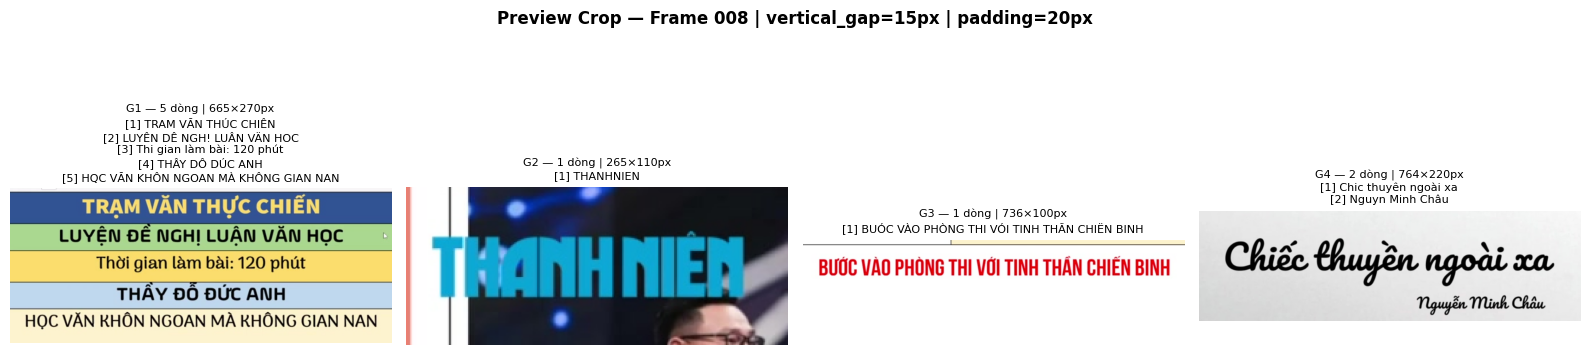

In [ ]:
# Chạy cell này để kiểm tra xem cấu hình khoảng cách gộp nhóm đã hợp lý chưa.
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
# Ẩn các cảnh báo thiếu ký tự glyph khi vẽ biểu đồ hiển thị OCR lỗi font tiếng Trung
warnings.filterwarnings("ignore", message=".*Glyph.*missing from font.*")
VIDEO_ID        = "L25_V001"
TARGET_FRAME_ID = "008"
OUTPUT_DIR      = Path("/content/mmrs_lmf/ocr_results")
VERTICAL_GAP   = 15   # Giữ nguyên độ cao vừa phải để tách độc lập tầng biển báo và logo
HORIZONTAL_GAP = 15  # TĂNG MẠNH khoảng cách ngang để xâu chuỗi toàn bộ dải chữ chạy ticker bên dưới lại với nhau
CROP_PADDING   = 20   # Tăng nhẹ viền crop để chữ sát rìa không bị mất nét khi nạp vào VLM

# Load dataframe từ Pass 1
df_raw   = pd.read_parquet(OUTPUT_DIR / f"{VIDEO_ID}_ppocrv6_raw.parquet")
df_frame = (df_raw[df_raw["frame_id"] == TARGET_FRAME_ID]
               .copy()
               .sort_values("line_idx"))
img       = Image.open(Path(df_frame["frame_path"].iloc[0])).convert("RGB")
groups    = group_bboxes_by_proximity(df_frame, vertical_gap=VERTICAL_GAP)

print(f"Frame {TARGET_FRAME_ID}: {len(df_frame)} bbox → {len(groups)} cụm (gap={VERTICAL_GAP}px)")
for g_id, g_idx in enumerate(groups):
    print(f"  G{g_id+1}: {df_frame.loc[g_idx, 'ocr_text'].tolist()}")

# Hiện kết quả trực quan
n_groups = len(groups)
fig, axes = plt.subplots(1, n_groups, figsize=(max(5, 4 * n_groups), 5))
if n_groups == 1:
    axes = [axes]

for g_id, g_idx in enumerate(groups):
    cropped, mbbox = crop_group_region(img, g_idx, df_frame, CROP_PADDING)
    g_texts        = df_frame.loc[g_idx, "ocr_text"].tolist()
    axes[g_id].imshow(cropped)
    title = f"G{g_id+1} — {len(g_idx)} dòng | {cropped.size[0]}×{cropped.size[1]}px\n"
    title += "\n".join(f"[{i+1}] {t}" for i, t in enumerate(g_texts))
    axes[g_id].set_title(title, fontsize=8)
    axes[g_id].axis("off")

plt.suptitle(
    f"Preview Crop — Frame {TARGET_FRAME_ID} | vertical_gap={VERTICAL_GAP}px | padding={CROP_PADDING}px",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.show()

📥 Đang tải kết quả PP-OCRv6 — Frame 008...
✅ 9 bboxes tìm thấy | Độ phân giải ảnh: 1280×720px

📦 Phân nhóm: 9 box → 4 cụm (vertical_gap=15px)
  [G1] 5 dòng | kích thước vùng crop: 665×270px | ['TRAM VĂN THÚC CHIÊN', 'LUYÊN DÊ NGH! LUÂN VÄN HOC', 'Thi gian làm bài: 120 phút', 'THÂY DÔ DÚC ANH', 'HQC VĂN KHÔN NGOAN MÀ KHÔNG GIAN NAN']
  [G2] 1 dòng | kích thước vùng crop: 265×110px | ['THANHNIEN']
  [G3] 1 dòng | kích thước vùng crop: 736×100px | ['BUÓC VÀO PHÒNG THI VÓI TINH THÃN CHIËN BINH']
  [G4] 2 dòng | kích thước vùng crop: 764×220px | ['Chic thuyên ngoài xa', 'Nguyn Minh Châu']

🚀 Đang tiến hành hiệu đính bằng Vintern-1B-v2 (4 cụm)...

  ┌─ [Cụm G1/4] 5 dòng | Crop size: (665, 270) | bbox: (np.int16(571), 0, np.int16(1236), np.int16(270))
  │  📝 Gốc: "TRAM VĂN THÚC CHIÊN"
  │  📝 Gốc: "LUYÊN DÊ NGH! LUÂN VÄN HOC"
  │  📝 Gốc: "Thi gian làm bài: 120 phút"
  │  📝 Gốc: "THÂY DÔ DÚC ANH"
  │  📝 Gốc: "HQC VĂN KHÔN NGOAN MÀ KHÔNG GIAN NAN"


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  │  ✏️ "TRAM VĂN THÚC CHIÊN"  →  "TRẠM VĂN THỰC CHIẾN"
  │  ✏️ "LUYÊN DÊ NGH! LUÂN VÄN HOC"  →  "LUYỆN ĐỀ NGHỊ LUẬN VĂN HỌC"
  │  ✏️ "Thi gian làm bài: 120 phút"  →  "Thời gian làm bài: 120 phút"
  │  ✏️ "THÂY DÔ DÚC ANH"  →  "THẦY ĐỖ ĐỨC ANH"
  │  ✏️ "HQC VĂN KHÔN NGOAN MÀ KHÔNG GIAN NAN"  →  "HỌC VĂN KHÔN NGOAN MÀ KHÔNG GIAN NÁN"
  └─ [Raw Vintern output]: [1] TRẠM VĂN THỰC CHIẾN
[2] LUYỆN ĐỀ NGHỊ LUẬN VĂN HỌC
[3] Thời gian làm bài: 120 phút
[4] THẦY ĐỖ ĐỨC ANH
[5] HỌC VĂN KHÔN NGOAN MÀ KHÔNG GIAN NÁN...

  ┌─ [Cụm G2/4] 1 dòng | Crop size: (265, 110) | bbox: (0, np.int16(9), np.int16(265), np.int16(119))
  │  📝 Gốc: "THANHNIEN"


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  │  ✅ "THANHNIEN"  →  "THANHNIEN"
  └─ [Raw Vintern output]: [1] THANHNIEN...

  ┌─ [Cụm G3/4] 1 dòng | Crop size: (736, 100) | bbox: (np.int16(272), np.int16(310), np.int16(1008), np.int16(410))
  │  📝 Gốc: "BUÓC VÀO PHÒNG THI VÓI TINH THÃN CHIËN BINH"


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  │  ✏️ "BUÓC VÀO PHÒNG THI VÓI TINH THÃN CHIËN BINH"  →  "BƯỚC VÀO PHÒNG THI VỚI TINH THẦN CHIẾN BINH"
  └─ [Raw Vintern output]: [1] BƯỚC VÀO PHÒNG THI VỚI TINH THẦN CHIẾN BINH...

  ┌─ [Cụm G4/4] 2 dòng | Crop size: (764, 220) | bbox: (np.int16(42), np.int16(500), np.int16(806), 720)
  │  📝 Gốc: "Chic thuyên ngoài xa"
  │  📝 Gốc: "Nguyn Minh Châu"


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  │  ✏️ "Chic thuyên ngoài xa"  →  "Chiếc thuyền ngoài xa"
  │  ✏️ "Nguyn Minh Châu"  →  "Nguyễn Minh Châu"
  └─ [Raw Vintern output]: [1] Chiếc thuyền ngoài xa
[2] Nguyễn Minh Châu...

💾 Đã lưu file kết quả: L25_V001_frame_008_vintern_corrected.parquet


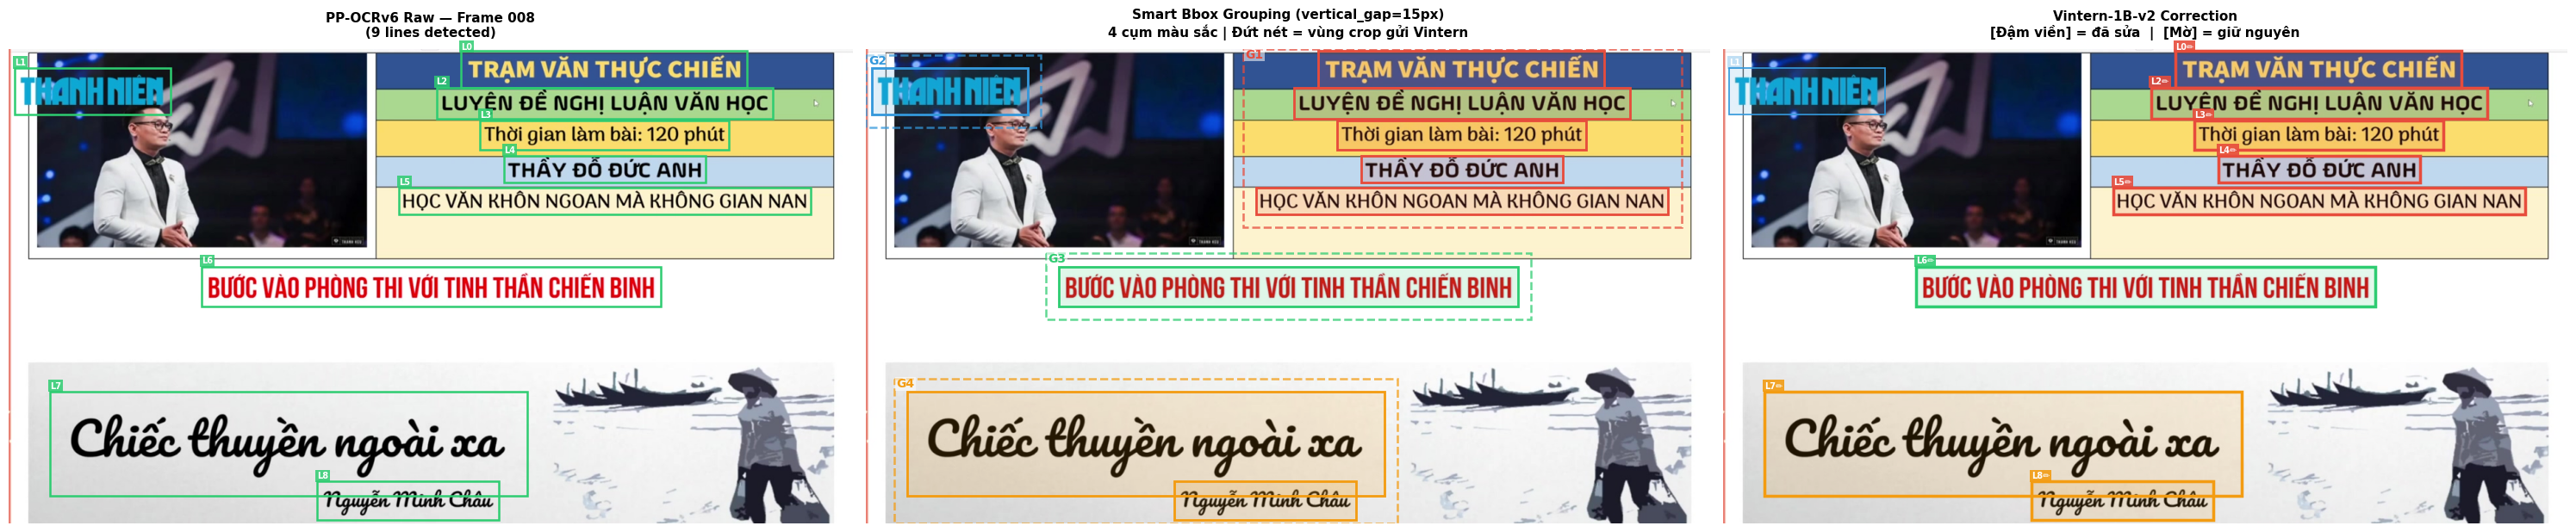

🖼  Biểu đồ trực quan hóa đã được lưu tại: L25_V001_frame_008_vintern_viz.png

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
   📊 BẢNG ĐỐI CHIẾU HIỆU ĐÍNH VINTERN-1B-V2 — FRAME 008
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Cụm Dòng   Conf                                  PP-OCR Gốc                                 Vintern Sửa   Trạng Thái
 G1   L0 0.9069                         TRAM VĂN THÚC CHIÊN                         TRẠM VĂN THỰC CHIẾN    ✏️ ĐÃ SỬA
 G2   L1 0.9926                                   THANHNIEN                                   THANHNIEN ✅ GIỮ NGUYÊN
 G1   L2 0.9565                  LUYÊN DÊ NGH! LUÂN VÄN HOC                  LUYỆN ĐỀ NGHỊ LUẬN VĂN HỌC    ✏️ ĐÃ SỬA
 G1   L3 0.9999                  Thi gian làm bài: 120 phút                 Thời gian làm bài: 120 phút    ✏️ ĐÃ SỬA
 G1   L4 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

# ─── CẤU HÌNH PIPELINE ────────────────────────────────────────────────────────────────
VIDEO_ID        = "L25_V001"
TARGET_FRAME_ID = "008"          # Thay đổi frame ID kiểm tra tại đây
OUTPUT_DIR      = Path("/content/mmrs_lmf/ocr_results")
VERTICAL_GAP   = 15   # Giữ nguyên độ cao vừa phải để tách độc lập tầng biển báo và logo
HORIZONTAL_GAP = 15  # TĂNG MẠNH khoảng cách ngang để xâu chuỗi toàn bộ dải chữ chạy ticker bên dưới lại với nhau
CROP_PADDING   = 20   # Tăng nhẹ viền crop để chữ sát rìa không bị mất nét khi nạp vào VLM

_COLORS = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6",
           "#1abc9c", "#e67e22", "#34495e", "#e91e63", "#00bcd4"]

# ─── 1. TẢI DỮ LIỆU PP-OCRv6 ─────────────────────────────────────────────────────────
print(f"📥 Đang tải kết quả PP-OCRv6 — Frame {TARGET_FRAME_ID}...")
df_raw   = pd.read_parquet(OUTPUT_DIR / f"{VIDEO_ID}_ppocrv6_raw.parquet")
df_frame = (df_raw[df_raw["frame_id"] == TARGET_FRAME_ID]
               .copy()
               .sort_values("line_idx"))

if df_frame.empty:
    raise RuntimeError(f"❌ Không tìm thấy Frame {TARGET_FRAME_ID} trong file parquet.")

img = Image.open(Path(df_frame["frame_path"].iloc[0])).convert("RGB")
print(f"✅ {len(df_frame)} bboxes tìm thấy | Độ phân giải ảnh: {img.size[0]}×{img.size[1]}px")


# ─── 2. PHÂN NHÓM BBOX ───────────────────────────────────────────────────────────────
groups = group_bboxes_by_proximity(df_frame, vertical_gap=VERTICAL_GAP)
print(f"\n📦 Phân nhóm: {len(df_frame)} box → {len(groups)} cụm (vertical_gap={VERTICAL_GAP}px)")
for g_id, g_idx in enumerate(groups):
    _, mbbox   = crop_group_region(img, g_idx, df_frame, CROP_PADDING)
    g_texts    = df_frame.loc[g_idx, "ocr_text"].tolist()
    crop_w     = mbbox[2] - mbbox[0]
    crop_h     = mbbox[3] - mbbox[1]
    print(f"  [G{g_id+1}] {len(g_idx)} dòng | kích thước vùng crop: {crop_w}×{crop_h}px | {g_texts}")


# ─── 3. CHẠY VINTERN CORRECTION ──────────────────────────────────────────────────────
print(f"\n🚀 Đang tiến hành hiệu đính bằng Vintern-1B-v2 ({len(groups)} cụm)...")

corrected_map = {}
group_id_map  = {}

for g_id, g_idx in enumerate(groups):
    g_texts           = df_frame.loc[g_idx, "ocr_text"].tolist()
    cropped, mbbox    = crop_group_region(img, g_idx, df_frame, CROP_PADDING)

    print(f"\n  ┌─ [Cụm G{g_id+1}/{len(groups)}] {len(g_idx)} dòng | Crop size: {cropped.size} | bbox: {mbbox}")
    for t in g_texts:
        print(f"  │  📝 Gốc: \"{t}\"")

    corrected_list, raw = call_vintern_correction(cropped, g_texts)

    for orig_idx, orig_t, corr_t in zip(g_idx, g_texts, corrected_list):
        corrected_map[orig_idx] = corr_t
        group_id_map[orig_idx]  = g_id
        flag = "✏️" if orig_t.strip() != corr_t.strip() else "✅"
        print(f"  │  {flag} \"{orig_t}\"  →  \"{corr_t}\"")

    print(f"  └─ [Raw Vintern output]: {raw[:160].strip()}...")


# ─── 4. CẬP NHẬT DATAFRAME & LƯU KẾT QUẢ ──────────────────────────────────────────────
df_frame["vintern_corrected_text"] = df_frame.index.map(corrected_map)
df_frame["text_changed"]           = (
    df_frame["ocr_text"].str.strip() != df_frame["vintern_corrected_text"].str.strip()
)
df_frame["group_id"] = df_frame.index.map(group_id_map)

out_parquet = OUTPUT_DIR / f"{VIDEO_ID}_frame_{TARGET_FRAME_ID}_vintern_corrected.parquet"
df_frame.to_parquet(out_parquet)
print(f"\n💾 Đã lưu file kết quả: {out_parquet.name}")


# ─── 5. VISUALIZE 3-PANEL DIAGRAM ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(30, 11))

# Panel A: PP-OCRv6 Raw
axes[0].imshow(img)
axes[0].set_title(f"PP-OCRv6 Raw — Frame {TARGET_FRAME_ID}\n({len(df_frame)} lines detected)", fontsize=11, fontweight="bold", pad=10)
axes[0].axis("off")
for _, row in df_frame.iterrows():
    x1, y1, x2, y2 = row["bbox"]
    axes[0].add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, lw=1.8, edgecolor="#2ecc71", facecolor="none"))
    axes[0].text(x1, max(0, y1 - 5), f"L{row['line_idx']}", color="white", fontsize=7, fontweight="bold",
                 bbox=dict(fc="#2ecc71", alpha=0.85, pad=1.5, ec="none"))

# Panel B: Smart Grouping Context
axes[1].imshow(img)
axes[1].set_title(f"Smart Bbox Grouping (vertical_gap={VERTICAL_GAP}px)\n{len(groups)} cụm màu sắc | Đứt nét = vùng crop gửi Vintern", fontsize=11, fontweight="bold", pad=10)
axes[1].axis("off")
for g_id, g_idx in enumerate(groups):
    gc = _COLORS[g_id % len(_COLORS)]
    for idx in g_idx:
        x1, y1, x2, y2 = df_frame.loc[idx, "bbox"]
        axes[1].add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, lw=2, edgecolor=gc, facecolor=gc, alpha=0.15))
        axes[1].add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, lw=2, edgecolor=gc, facecolor="none"))

    _, (mx1, my1, mx2, my2) = crop_group_region(img, g_idx, df_frame, CROP_PADDING)
    axes[1].add_patch(patches.Rectangle((mx1, my1), mx2-mx1, my2-my1, lw=1.8, edgecolor=gc, facecolor="none", linestyle="--", alpha=0.75))
    axes[1].text(mx1 + 4, my1 + 13, f"G{g_id+1}", color=gc, fontsize=10, fontweight="bold", bbox=dict(fc="white", alpha=0.55, pad=1, ec="none"))

# Panel C: Vintern Correction Output
axes[2].imshow(img)
axes[2].set_title("Vintern-1B-v2 Correction\n[Đậm viền] = đã sửa  |  [Mờ] = giữ nguyên", fontsize=11, fontweight="bold", pad=10)
axes[2].axis("off")
for _, row in df_frame.iterrows():
    x1, y1, x2, y2 = row["bbox"]
    gc    = _COLORS[row["group_id"] % len(_COLORS)]
    alpha = 0.9  if row["text_changed"] else 0.30
    lw    = 2.5  if row["text_changed"] else 1.2
    axes[2].add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, lw=lw, edgecolor=gc, facecolor=gc, alpha=0.13))
    axes[2].add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, lw=lw, edgecolor=gc, facecolor="none"))
    label = f"L{row['line_idx']}{'✏' if row['text_changed'] else ''}"
    axes[2].text(x1, max(0, y1 - 5), label, color="white", fontsize=7, fontweight="bold", bbox=dict(fc=gc, alpha=alpha, pad=1.5, ec="none"))

plt.tight_layout()
viz_path = OUTPUT_DIR / f"{VIDEO_ID}_frame_{TARGET_FRAME_ID}_vintern_viz.png"
plt.savefig(viz_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"🖼  Biểu đồ trực quan hóa đã được lưu tại: {viz_path.name}")


# ─── 6. BẢNG ĐỐI CHIẾU CHI TIẾT (REPORT) ──────────────────────────────────────────────
_SEP = "═" * 135
print(f"\n{_SEP}")
print(f"   📊 BẢNG ĐỐI CHIẾU HIỆU ĐÍNH VINTERN-1B-V2 — FRAME {TARGET_FRAME_ID}")
print(_SEP)

report = [
    {
        "Cụm":         f"G{row['group_id'] + 1}",
        "Dòng":        f"L{row['line_idx']}",
        "Conf":        f"{row['confidence']:.4f}",
        "PP-OCR Gốc":  row["ocr_text"],
        "Vintern Sửa": row["vintern_corrected_text"],
        "Trạng Thái":  "✏️ ĐÃ SỬA" if row["text_changed"] else "✅ GIỮ NGUYÊN",
    }
    for _, row in df_frame.sort_values("line_idx").iterrows()
]

df_report = pd.DataFrame(report)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 260)
print(df_report.to_string(index=False))

n_changed = df_frame["text_changed"].sum()
print(f"\n{'─'*60}")
print(f"  Tổng: {len(df_frame)} dòng | ✏️ Sửa: {n_changed} | ✅ Giữ nguyên: {len(df_frame) - n_changed}")
print(f"{'─'*60}")